In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
import joblib, json, os, warnings
warnings.filterwarnings('ignore')

train = pd.read_parquet('../data/processed/train_woe.parquet')
oot = pd.read_parquet('../data/processed/oot_woe.parquet')

TARGET = 'TARGET'
# 注释代码：原本打算从json文件读取特征名，当前弃用
# with open('../models/feature_names.json') as f:
#     features = json.load(f)

X_train = train.drop(columns=[TARGET])
features = X_train.columns
y_train = train[TARGET]

X_oot = oot.drop(columns=[TARGET])
y_oot = oot[TARGET]

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"Holdout: {X_oot.shape},  default rate: {y_oot.mean():.3f}")

Train: (246008, 56), default rate: 0.081
Holdout: (61503, 56),  default rate: 0.081


In [2]:
def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4)

def gini(y_true, y_prob):
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)

def evaluate(name, y_tr, p_tr, y_ot, p_ot):
    return {
        'Model'     : name,
        'AUC Train' : round(roc_auc_score(y_tr, p_tr), 4),
        'AUC Holdout'   : round(roc_auc_score(y_ot, p_ot), 4),
        'KS Train'  : ks_stat(y_tr, p_tr),
        'KS Holdout'    : ks_stat(y_ot, p_ot),
        'Gini Train': gini(y_tr, p_tr),
        'Gini Holdout'  : gini(y_ot, p_ot),
    }

In [3]:
# 利用交叉验证寻找最优树数量；
# 留出集不参与调参，仅用于最终评估（防止在OOT上过拟合）
params = {
    'objective'     : 'binary',        # 二分类任务（逾期预测）
    'metric'        : 'auc',           # 交叉验证优化指标AUC
    'learning_rate' : 0.05,            # 学习率
    'num_leaves'    : 31,              # 单棵树最大叶子节点
    'max_depth'     : -1,              # -1：由num_leaves自动控制树深
    'min_child_samples': 50,           # 叶子最少样本数，抑制过拟合
    'subsample'     : 0.8,             # 每棵树随机抽取80%样本
    'colsample_bytree': 0.8,           # 每棵树随机选取80%特征
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(), # 正负样本权重，解决样本不平衡
    'random_state'  : 42,              # 随机种子保证复现
    'verbose'       : -1               # 关闭多余日志输出
}

dtrain = lgb.Dataset(X_train, label=y_train)

cv_results = lgb.cv(
    params,
    dtrain,
    num_boost_round=1000,     # 最大尝试树数量1000
    nfold=5,                  # 5折交叉验证
    stratified=True,          # 分层抽样，保证每折好坏客户比例一致
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    # 早停：连续50轮验证AUC不提升就停止；每训练100棵打印日志
)

best_n = len(cv_results['valid auc-mean'])
best_auc_cv = max(cv_results['valid auc-mean'])
print(f"\nBest n_estimators: {best_n}")
print(f"Best CV AUC: {best_auc_cv:.4f}")

Training until validation scores don't improve for 50 rounds


[100]	valid's auc: 0.767224 + 0.00325364


[200]	valid's auc: 0.771322 + 0.00353341


[300]	valid's auc: 0.771791 + 0.0032179


[400]	valid's auc: 0.771857 + 0.00316541


Early stopping, best iteration is:
[371]	valid's auc: 0.77191 + 0.00320513

Best n_estimators: 371
Best CV AUC: 0.7719


In [4]:
# 导入之前params字典全部参数，剔除'metric'（LGBMClassifier不识别该参数）
# n_estimators使用交叉验证找到的最优树数量best_n
lgbm = lgb.LGBMClassifier(
    **{k: v for k, v in params.items() if k != 'metric'},
    n_estimators=best_n,
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_oot, y_oot)],       # 训练过程监控留出集效果
    callbacks=[lgb.log_evaluation(100)] # 每训练100棵树打印评估日志
)

# predict_proba输出[非违约概率,违约概率]，[:,1]取出违约概率
p_train = lgbm.predict_proba(X_train)[:, 1]
p_oot   = lgbm.predict_proba(X_oot)[:, 1]

lgbm_res = evaluate('LightGBM', y_train, p_train, y_oot, p_oot)
print(lgbm_res)

[100]	valid_0's binary_logloss: 0.562492


[200]	valid_0's binary_logloss: 0.552901


[300]	valid_0's binary_logloss: 0.544491


{'Model': 'LightGBM', 'AUC Train': 0.8278, 'AUC Holdout': 0.7723, 'KS Train': np.float64(0.4987), 'KS Holdout': np.float64(0.4149), 'Gini Train': 0.6557, 'Gini Holdout': 0.5446}


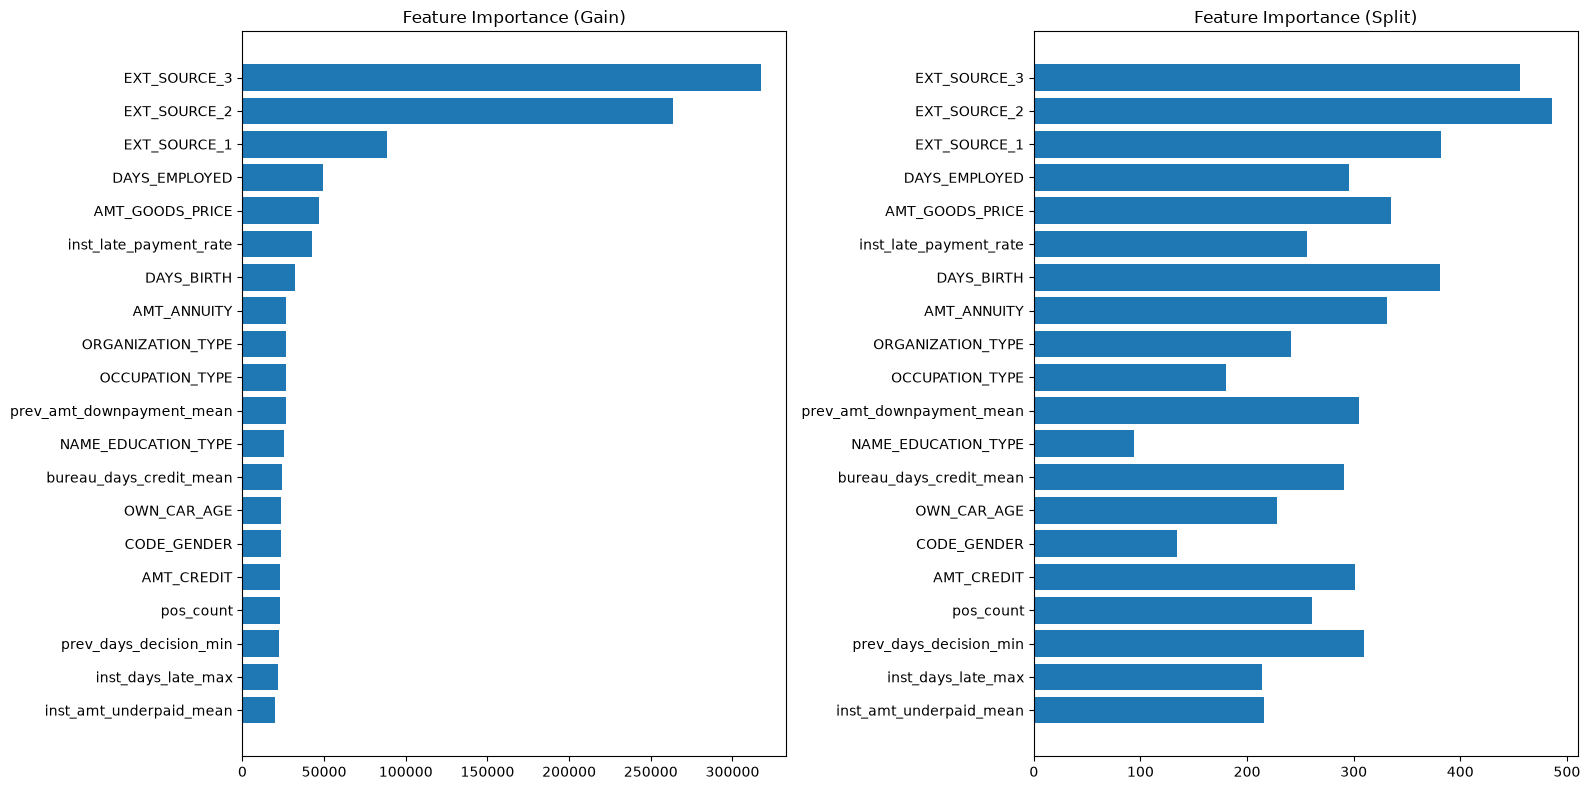

In [5]:
importance_df = pd.DataFrame({
    'feature' : features,
    'gain'    : lgbm.booster_.feature_importance(importance_type='gain'),   # gain：特征分裂带来总信息增益（风控优先参考）
    'split'   : lgbm.booster_.feature_importance(importance_type='split'),  # split：特征被用来分裂节点的总次数
}).sort_values('gain', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, col, title in zip(axes,
                          ['gain', 'split'],
                          ['Feature Importance (Gain)', 'Feature Importance (Split)']):
    top = importance_df.head(20)
    ax.barh(top['feature'], top[col])
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

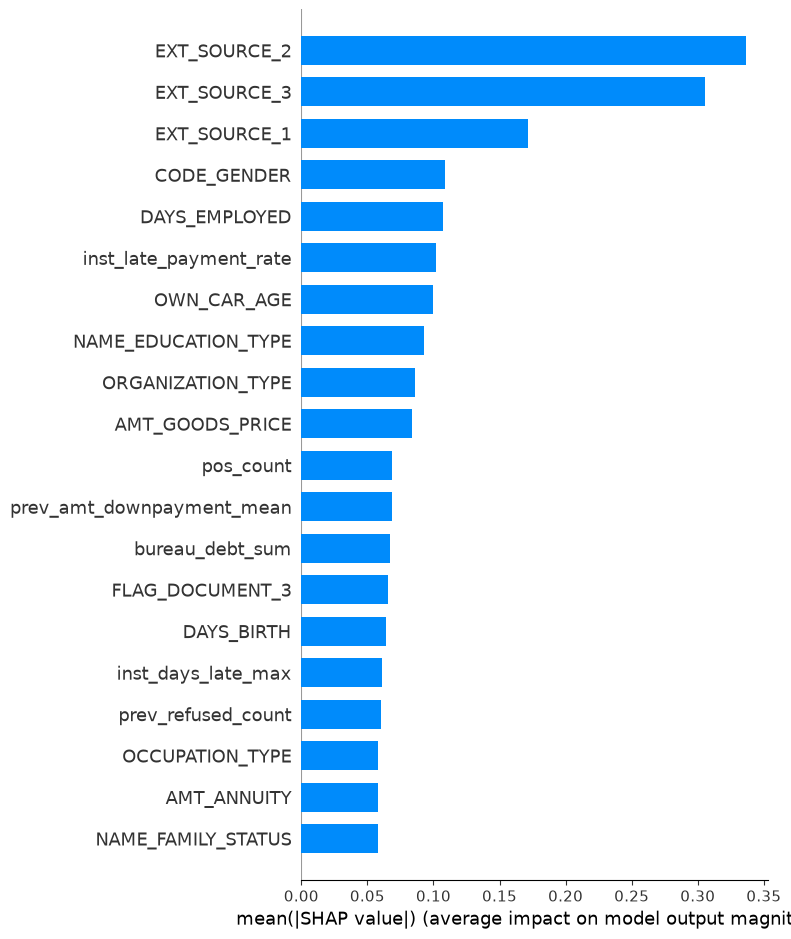

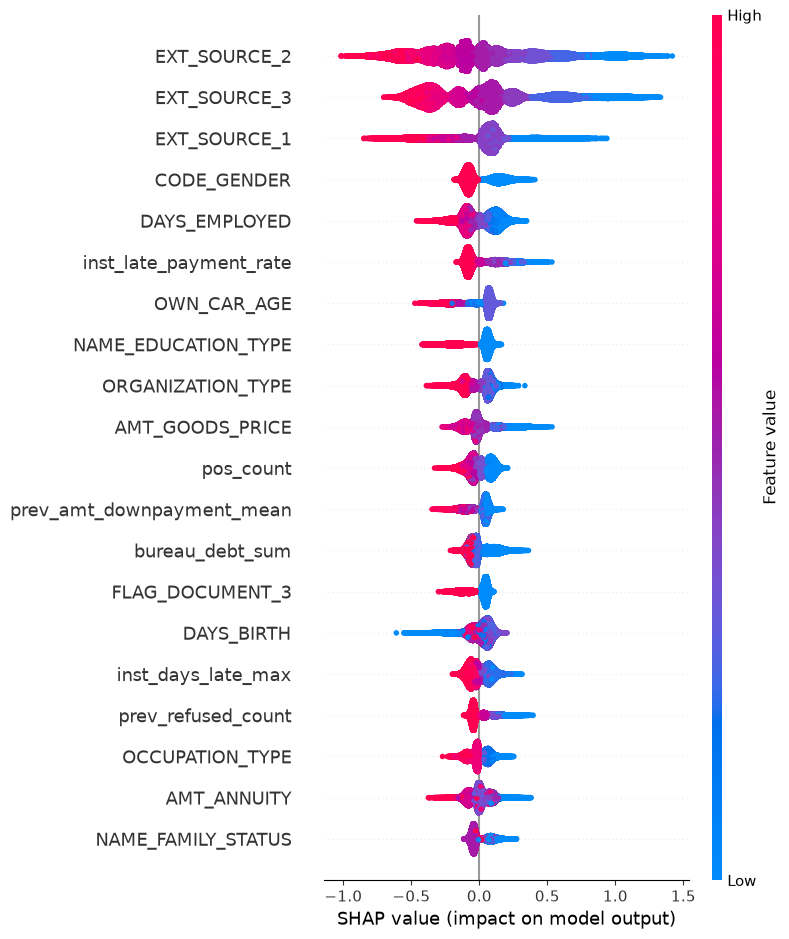

In [6]:
# 针对树模型创建SHAP解释器，用于LightGBM模型解释
explainer = shap.TreeExplainer(lgbm)


# 计算训练集所有样本每条特征对应的SHAP值
shap_values = explainer.shap_values(X_train)
#SHAP 正负号：影响方向
#SHAP＞0 → 这个特征让客户更容易逾期
#SHAP＜0 → 这个特征让客户更安全、不容易逾期
#SHAP 绝对值大小：影响力度
#绝对值越大，这条特征对该客户风险打分影响力越强
#SHAP=0：这条特征对这个客户几乎不起作用


# 绘制SHAP条形汇总图：展示全局特征重要性（SHAP绝对值均值）
shap.summary_plot(
    shap_values,
    X_train,
    plot_type='bar',   # 图表类型：条形图，只看重要性大小
    max_display=20,    # 最多展示排名前20的特征
    show=True
)

# 绘制SHAP散点汇总图（蜂群图）：观察特征取值如何影响预测结果
shap.summary_plot(
    shap_values,
    X_train,
    max_display=20,
    show=True
)

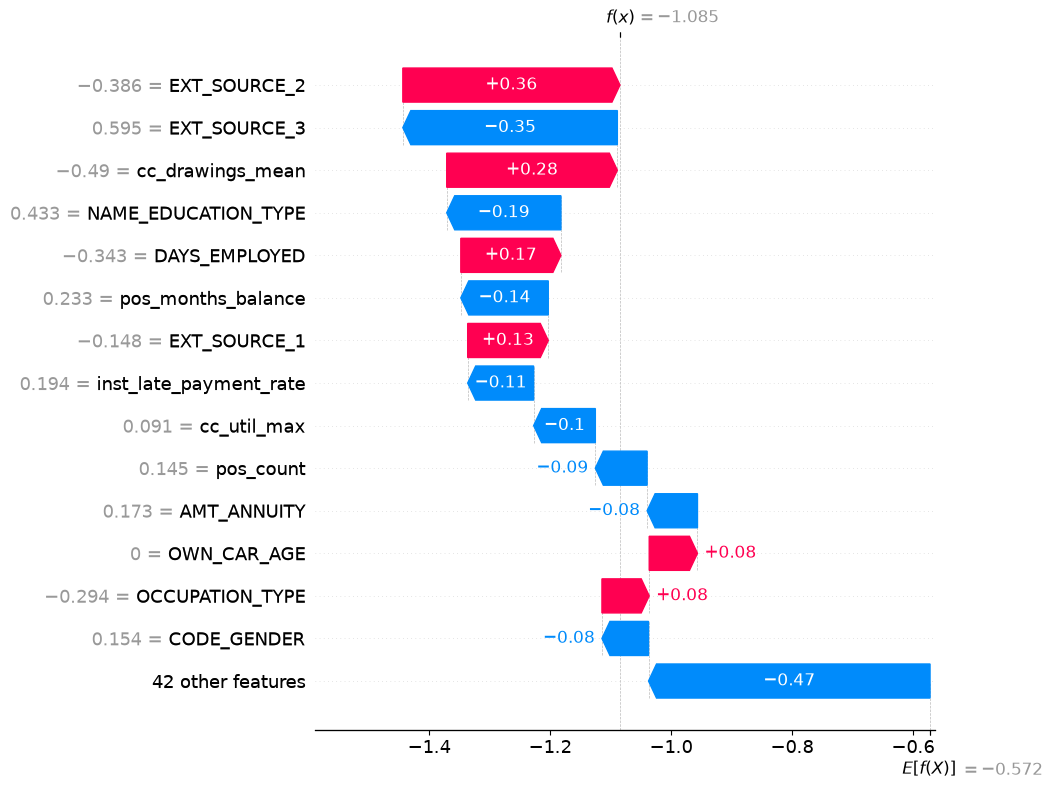

In [7]:
# 选取训练集第0号客户，绘制SHAP瀑布图，单样本逐特征解释预测结果
sample_idx = 0

# 组装SHAP解释对象，封装单个客户完整解释信息
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],        # 当前客户每条特征对应的SHAP贡献值
    base_values=explainer.expected_value,   # 基准值：全体样本模型平均输出
    data=X_train.iloc[sample_idx],         # 当前客户各个特征原始取值
    feature_names=features
)

# 绘制SHAP瀑布图，最多展示影响力前15个特征，可视化单客户风险构成
shap.waterfall_plot(shap_explanation, max_display=15, show=True)

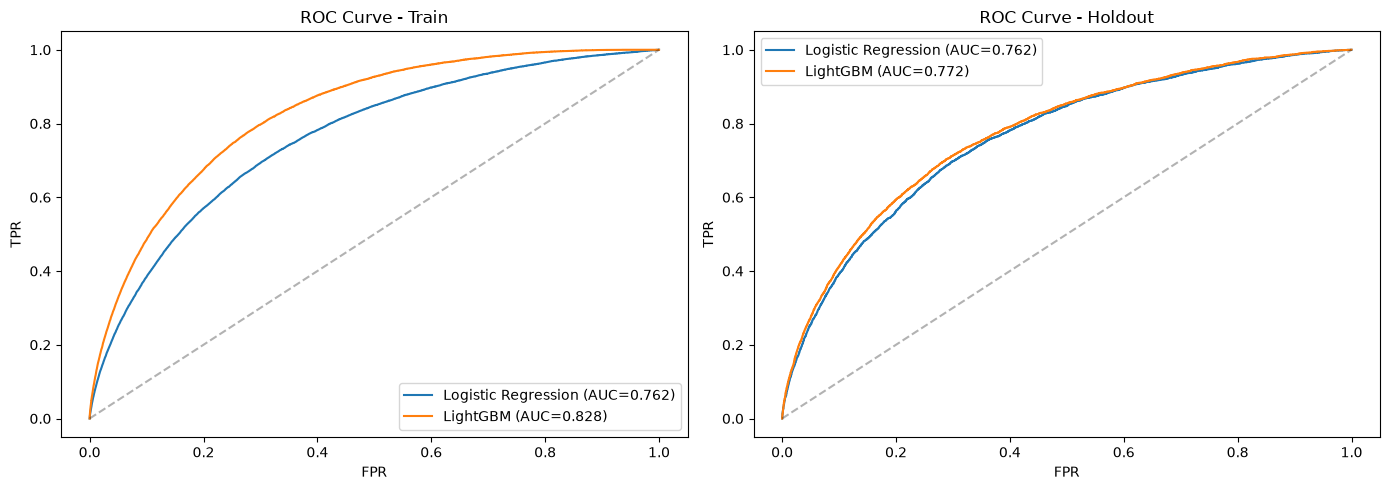

In [8]:
# 加载训练好的WOE逻辑回归模型，分别在训练集、留出集跨时间样本上预测违约概率
lr = joblib.load('../models/logreg_woe.pkl')
p_lr_train = lr.predict_proba(X_train)[:, 1]
p_lr_oot   = lr.predict_proba(X_oot)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, p_lr, p_lgbm, label) in zip(axes, [
    (y_train, p_lr_train, p_train, 'Train'),
    (y_oot,  p_lr_oot,   p_oot,  'Holdout'),
]):
    for probs, name in [(p_lr, 'Logistic Regression'), (p_lgbm, 'LightGBM')]:
        fpr, tpr, _ = roc_curve(y, probs)
        auc = roc_auc_score(y, probs)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC Curve - {label}')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
plt.show()



In [9]:
joblib.dump(lgbm, '../models/lgbm_model.pkl')
print("Saved: models/lgbm_model.pkl")

# 保存训练集对应的全部样本SHAP贡献矩阵，后续可视化可直接加载，避免重复计算
np.save('../models/shap_values_train.npy', shap_values)
print("Saved: models/shap_values_train.npy")



Saved: models/lgbm_model.pkl


Saved: models/shap_values_train.npy


## LightGBM Model Summary

### Model Choice for Scorecard
Logistic Regression is selected for the scorecard (notebook 07) due to:
- Full interpretability — each feature has a single coefficient
- Regulatory compliance — explainable to auditors and regulators
- Competitive AUC within acceptable range for retail credit scoring
LightGBM serves as performance benchmark.

**Next step:** Scorecard → notebook 07